This project uses data analysis and preprocessing on the dataset to standardize features and omit unnecessary data. This helps to put a better focus on the certain features of the dataset that can support the problem statement. To predict the outcome of a movie's success by using certain factors such as budget, revenue, and popularity. The prediction of this success is that I will see a high variability in the spread considering the sample set is over 1,000,000 entries. The success class of low, medium, and high is better to understand through the visualizations considering the factors of finances and popularity is what production companies will have to decide on for making sequels and remakes.

## Import Utils

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

## Data Loading and Preprocessing

My data was retrieved from a dataset that is publicly available on the Kaggle Platform. The dataset is titled “Full TMDB Movies Dataset 2024” (1M Movies) and it contains various data about movies from TMDb (The Movie Database) that is updated daily  Before I utilize preprocessing, the user “asnaiczka” created the list which contains over 1,000,000 samples and has 24 attributes (features) involved for the film information (1). The table coming up lists all the columns in the database that were originally in the dataset before preprocessing is used to omit unnecessary data and standardize some of the data along with creating the success classes. 

In [2]:
df = pd.read_csv('TMDB_movie_dataset_v11.csv')

print(f"Original shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Original shape: (1329859, 24)
Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']


In [3]:
def create_success_classes_column_based(df, roi_weight=0.6, rating_weight=0.4):
    """
    Create success classes using weighted method with FIXED thresholds
    
    ROI Classes:
    - Low: ROI ≤ 1.33 (revenue ≤ budget × 1.33)
    - Medium: 1.33 < ROI ≤ 1.67
    - High: ROI > 1.67
    
    Rating Classes:
    - Low: 0.0 ≤ vote_average ≤ 7.7
    - Medium: 7.8 ≤ vote_average ≤ 8.8
    - High: 8.9 ≤ vote_average ≤ 10.0
    
    FINAL SUCCESS CLASSES (based on weighted score 0-100):
    - Low: 0.0 ≤ success_score ≤ 50.0
    - Medium: 50.1 ≤ success_score ≤ 70.0
    - High: 70.1 ≤ success_score ≤ 100.0
    """
    df = df.copy()
    
    # Calculate ROI safely (handle zero/NaN budgets)
    df['ROI'] = np.where(df['budget'] > 0, df['revenue'] / df['budget'], 0)
    
    # Fill missing vote_average with median
    if df['vote_average'].isna().any():
        df['vote_average'] = df['vote_average'].fillna(df['vote_average'].median())
    
    # Calculate ROI component (0-100 scale)
    conditions_roi = [
        df['ROI'] <= 1.33,
        (df['ROI'] > 1.33) & (df['ROI'] <= 1.67),
        df['ROI'] > 1.67
    ]
    
    choices_roi = [
        (df['ROI'] / 1.33) * 33,
        33 + ((df['ROI'] - 1.33) / 0.34) * 33,
        66 + ((df['ROI'] - 1.67) / 8.33) * 34
    ]
    
    roi_score = np.select(conditions_roi, choices_roi, default=50)
    
    # Calculate rating component (0-100 scale) - UPDATED THRESHOLDS
    conditions_rating = [
        df['vote_average'] <= 7.7,
        (df['vote_average'] > 7.7) & (df['vote_average'] <= 8.8),
        df['vote_average'] > 8.8
    ]
    
    choices_rating = [
        (df['vote_average'] / 7.7) * 33,
        33 + ((df['vote_average'] - 7.7) / 1.1) * 33,
        66 + ((df['vote_average'] - 8.8) / 1.2) * 34
    ]
    
    rating_score = np.select(conditions_rating, choices_rating, default=50)
    
    # Calculate weighted success score (0-100 scale)
    df['success_score'] = (roi_score * roi_weight) + (rating_score * rating_weight)
    
    # Cap the success score at 100
    df['success_score'] = np.clip(df['success_score'], 0, 100)
    
    # Assign classes based on FIXED thresholds
    conditions = [
        df['success_score'] <= 50.0,
        (df['success_score'] > 50.0) & (df['success_score'] <= 70.0),
        df['success_score'] > 70.0
    ]
    
    choices = ['Low', 'Medium', 'High']
    
    df['success_class'] = np.select(conditions, choices, default='Medium')
    
    return df

In [4]:
def preprocess_movies(df):
    """
    Simplified preprocessing based on your provided code
    """
    # Step 1: Drop specified columns
    columns_to_drop = [
        'id', 'adult', 'keywords', 'backdrop_path', 'homepage',
        'imdb_id', 'original_title', 'overview', 'poster_path',
        'tagline', 'popularity', 'production_companies', 'roi_class', 'rating_class'
    ]
    
    # Only drop columns that exist
    existing_columns = [col for col in columns_to_drop if col in df.columns]
    df = df.drop(columns=existing_columns)
    print(f"Dropped {len(existing_columns)} columns")
    
    # Step 2: Remove entries with zero values in success columns
    success_cols = ['budget', 'revenue', 'vote_average']
    existing_success = [col for col in success_cols if col in df.columns]
    
    if existing_success:
        mask = pd.Series([False] * len(df))
        for col in existing_success:
            if pd.api.types.is_numeric_dtype(df[col]):
                col_mask = (df[col] <= 0) | df[col].isna()
                mask = mask | col_mask
                print(f"Found {col_mask.sum()} rows with invalid {col}")
        
        df = df[~mask].reset_index(drop=True)
        print(f"Removed {mask.sum()} entries with invalid success values")
    
    return df

In [5]:
print("Creating success classes...")
df_with_classes = create_success_classes_column_based(df)

print("\nPreprocessing data...")
df_processed = preprocess_movies(df_with_classes)

print(f"\nFinal dataset shape: {df_processed.shape}")
print("Success class distribution:")
print(df_processed['success_class'].value_counts())

Creating success classes...

Preprocessing data...
Dropped 12 columns
Found 1255900 rows with invalid budget
Found 1306785 rows with invalid revenue
Found 974011 rows with invalid vote_average
Removed 1318703 entries with invalid success values

Final dataset shape: (11156, 15)
Success class distribution:
success_class
Low       5323
Medium    4464
High      1369
Name: count, dtype: int64


In [6]:
display(df_processed)

,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,original_language,genres,production_countries,spoken_languages,ROI,success_score,success_class
0,Inception,8.364,34495,Released,2010-07-15,825532764,148,160000000,en,"Action, Science Fiction, Adventure","United Kingdom, United States of America","English, French, Japanese, Swahili",5.159580,69.313910,Medium
1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,165000000,en,"Adventure, Drama, Science Fiction","United Kingdom, United States of America",English,4.252904,67.729480,Medium
2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,185000000,en,"Drama, Action, Crime, Thriller","United Kingdom, United States of America","English, Mandarin",5.430046,71.752275,High
3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,237000000,en,"Action, Adventure, Fantasy, Science Fiction","United States of America, United Kingdom","English, Spanish",12.336312,78.703867,High
4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,220000000,en,"Science Fiction, Action, Adventure",United States of America,"English, Hindi, Russian",6.903707,65.737241,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11151,Undercover,10.000,1,Released,2021-02-20,2,4,110,en,"Thriller, Crime",United Kingdom,English,0.018182,40.270677,Low
11152,Щенок и старая тапочка,9.000,1,Released,1987-02-20,100,0,100,ru,Animation,Soviet Union,Russian,1.000000,43.553885,Low
11153,Your happiness in life,10.000,0,Released,2025-06-17,35,0,40,ar,"Adventure, Drama",Saudi Arabia,"English, Italian, Arabic",0.875000,53.026316,Medium
11154,Skeye Hallelujah Cover,7.000,0,Released,2010-12-06,1000,6,1000,en,"Music, Drama",NaN,NaN,1.000000,26.887218,Low


## Plotting and Displaying Visualizations

In [7]:
def plot_success_distribution_simple(df):
    """
    Simple plot of success distribution
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar chart
    counts = df['success_class'].value_counts().sort_index()
    colors = ['lightcoral', 'wheat', 'lightgreen']
    
    bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='black')
    ax1.set_title('Success Class Distribution', fontweight='bold')
    ax1.set_xlabel('Success Class')
    ax1.set_ylabel('Number of Movies')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add counts on bars
    for bar, count in zip(bars, counts.values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 5,
                f'{count}', ha='center', va='bottom', fontweight='bold')
    
    # Histogram of success scores
    ax2.hist(df['success_score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax2.axvline(50, color='red', linestyle='--', alpha=0.7, label='Low/Medium (50)')
    ax2.axvline(70, color='orange', linestyle='--', alpha=0.7, label='Medium/High (70)')
    ax2.set_title('Distribution of Success Scores', fontweight='bold')
    ax2.set_xlabel('Success Score (0-100)')
    ax2.set_ylabel('Number of Movies')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.suptitle(f'Movie Success Analysis (n={len(df)})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def extract_comma_separated_genres(df, genres_col='genres'):
    """Extract genres from comma-separated strings"""
    df_genres = df.copy()
    df_genres[genres_col] = df_genres[genres_col].fillna('')
    df_genres['genre_list'] = df_genres[genres_col].str.split(',')
    df_genres['genre_list'] = df_genres['genre_list'].apply(
        lambda x: [g.strip() for g in x if g.strip()] if isinstance(x, list) else []
    )
    
    exploded = df_genres.explode('genre_list')
    exploded = exploded.rename(columns={'genre_list': 'genre'})
    exploded = exploded[exploded['genre'] != '']
    
    return exploded.reset_index(drop=True)

In [8]:
def plot_most_popular_genres(df, genres_col='genres', top_n=15, figsize=(16, 12)):
    """
    Plot most popular genres in the dataset with success breakdown
    INCLUDES: Percentages for each genre and pie chart for success distribution
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Extract genres
    df_genres = extract_comma_separated_genres(df, genres_col)
    
    # Get top N genres by frequency
    genre_counts = df_genres['genre'].value_counts().head(top_n)
    
    # Get success breakdown for top genres
    if 'success_class' in df_genres.columns:
        genre_success = pd.crosstab(df_genres['genre'], df_genres['success_class'])
    else:
        # If success_class not in exploded df, merge it back
        temp = pd.merge(df_genres[['title', 'genre']], 
                       df[['title', 'success_class']], 
                       on='title', how='left')
        genre_success = pd.crosstab(temp['genre'], temp['success_class'])
    
    # Only keep top N genres
    top_genres = genre_counts.index.tolist()
    genre_success = genre_success.loc[top_genres]
    
    # Reorder columns to Low, Medium, High
    success_order = ['Low', 'Medium', 'High']
    available_cols = [col for col in success_order if col in genre_success.columns]
    genre_success = genre_success[available_cols]
    
    # Calculate percentages
    genre_percentages = genre_success.div(genre_success.sum(axis=1), axis=0) * 100
    
    # Create figure with 3 subplots
    fig = plt.figure(figsize=figsize)
    
    # Create grid: 2 rows, 2 columns
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1.5, 1])
    
    ax1 = fig.add_subplot(gs[0, 0])  # Top left: Genre popularity bar chart
    ax2 = fig.add_subplot(gs[1, 0])  # Bottom left: Genre success stacked bar
    ax3 = fig.add_subplot(gs[0, 1])  # Top right: Success class pie chart
    ax4 = fig.add_subplot(gs[1, 1])  # Bottom right: Genre percentage heatmap
    
    # 1. Bar chart: Total number of movies per genre
    colors1 = plt.cm.Set3(np.linspace(0, 1, len(top_genres)))
    bars1 = ax1.barh(range(len(top_genres)), genre_counts.values, color=colors1, edgecolor='black')
    ax1.set_yticks(range(len(top_genres)))
    ax1.set_yticklabels(top_genres)
    ax1.invert_yaxis()
    ax1.set_xlabel('Number of Movies', fontsize=11)
    ax1.set_title(f'Top {top_n} Most Popular Genres', fontsize=13, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add count labels with percentage of total
    total_genre_entries = len(df_genres)
    for i, (bar, count) in enumerate(zip(bars1, genre_counts.values)):
        percentage = (count / total_genre_entries) * 100
        label = f'{count} ({percentage:.1f}%)'
        ax1.text(bar.get_width() + max(genre_counts.values)*0.01, i, 
                label, va='center', fontsize=9, fontweight='bold')
    
    # 2. Stacked bar chart: Success breakdown per genre WITH PERCENTAGES
    success_colors = ['lightcoral', 'wheat', 'lightgreen'][:len(available_cols)]
    
    bottom = np.zeros(len(top_genres))
    for i, success_class in enumerate(available_cols):
        ax2.barh(range(len(top_genres)), genre_success[success_class].values, 
                left=bottom, color=success_colors[i], edgecolor='black', 
                alpha=0.8, label=success_class)
        bottom += genre_success[success_class].values
    
    ax2.set_yticks(range(len(top_genres)))
    ax2.set_yticklabels(top_genres)
    ax2.invert_yaxis()
    ax2.set_xlabel('Number of Movies', fontsize=11)
    ax2.set_title('Success Class Breakdown by Genre', fontsize=13, fontweight='bold')
    ax2.legend(title='Success Class', loc='lower right', fontsize=9)
    ax2.grid(axis='x', alpha=0.3)
    
    # Add success percentages on each segment
    for i, genre in enumerate(top_genres):
        total = genre_counts[genre]
        segment_bottom = 0
        for j, success_class in enumerate(available_cols):
            count = genre_success.loc[genre, success_class]
            if count > 0:
                percentage = genre_percentages.loc[genre, success_class]
                # Position text in middle of segment
                text_x = segment_bottom + count/2
                # Only show percentage if segment is large enough
                if count > total * 0.1:  # Only if >10% of this genre
                    ax2.text(text_x, i, f'{percentage:.0f}%', 
                            ha='center', va='center', fontsize=8, fontweight='bold',
                            color='white' if percentage > 30 else 'black')
                segment_bottom += count
    
    # 3. PIE CHART: Overall success class distribution
    if 'success_class' in df.columns:
        success_counts = df['success_class'].value_counts().sort_index()
        pie_colors = ['lightcoral', 'wheat', 'lightgreen'][:len(success_counts)]
        
        wedges, texts, autotexts = ax3.pie(
            success_counts.values, 
            labels=success_counts.index,
            autopct='%1.1f%%',
            colors=pie_colors,
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.8}
        )
        
        # Style the text
        plt.setp(autotexts, size=10, weight="bold", color='black')
        plt.setp(texts, size=10, weight="bold")
        ax3.set_title('Overall Success Class Distribution', fontsize=13, fontweight='bold', pad=20)
        
        # Add count in center
        total_movies = len(df)
        ax3.text(0, 0, f'n={total_movies}', ha='center', va='center', 
                fontsize=11, fontweight='bold', style='italic')
    else:
        ax3.text(0.5, 0.5, 'Success class data\nnot available', 
                ha='center', va='center', transform=ax3.transAxes, fontsize=12)
        ax3.set_title('Success Distribution', fontsize=13, fontweight='bold')
    
    # 4. Heatmap: Success percentage per genre
    im = ax4.imshow(genre_percentages.T, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
    
    # Set ticks and labels
    ax4.set_xticks(range(len(top_genres)))
    ax4.set_xticklabels(top_genres, rotation=45, ha='right', fontsize=9)
    ax4.set_yticks(range(len(available_cols)))
    ax4.set_yticklabels(available_cols, fontsize=10)
    
    # Add text annotations with percentages
    for i in range(len(top_genres)):
        for j in range(len(available_cols)):
            value = genre_percentages.iloc[i, j]
            if value > 1:  # Only show text for >1%
                text_color = 'white' if value > 50 else 'black'
                ax4.text(i, j, f'{value:.0f}%', 
                        ha='center', va='center', 
                        color=text_color,
                        fontsize=8, fontweight='bold')
    
    ax4.set_title('Success Percentage by Genre', fontsize=13, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax4, orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label('Percentage (%)', fontsize=10)
    
    plt.suptitle(f'Comprehensive Genre & Success Analysis (n={len(df)} movies)', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print detailed genre statistics WITH PERCENTAGES
    print("="*70)
    print(f"TOP {top_n} GENRE STATISTICS WITH PERCENTAGES")
    print("="*70)
    
    # Calculate overall success distribution for comparison
    if 'success_class' in df.columns:
        overall_success = df['success_class'].value_counts(normalize=True) * 100
        print(f"\nOverall Success Distribution:")
        for cls in ['Low', 'Medium', 'High']:
            if cls in overall_success:
                print(f"  {cls}: {overall_success[cls]:.1f}%")
    
    print(f"\nGenre Success Breakdown:")
    print("-" * 70)
    
    for genre in top_genres:
        total = genre_counts[genre]
        genre_pct_of_total = (total / total_genre_entries) * 100
        
        # Get success percentages
        high_pct = genre_percentages.loc[genre, 'High'] if 'High' in genre_percentages.columns else 0
        medium_pct = genre_percentages.loc[genre, 'Medium'] if 'Medium' in genre_percentages.columns else 0
        low_pct = genre_percentages.loc[genre, 'Low'] if 'Low' in genre_percentages.columns else 0
        
        # Calculate if genre performs better/worse than average
        if 'success_class' in df.columns:
            if 'High' in overall_success:
                high_diff = high_pct - overall_success['High']
                perf = "↑" if high_diff > 5 else ("↓" if high_diff < -5 else "→")
            else:
                perf = ""
        else:
            perf = ""
        
        success_trend = ""
        if high_pct > 50:
            success_trend = "🏆 Excellent"
        elif high_pct > 40:
            success_trend = "✅ Strong"
        elif medium_pct > 60:
            success_trend = "⚖️ Balanced"
        elif low_pct > 60:
            success_trend = "⚠️ Challenging"
        else:
            success_trend = "📊 Mixed"
        
        print(f"{genre:20} {total:4d} movies ({genre_pct_of_total:5.1f}% of all genre entries)")
        print(f"  {' ' * 22}High: {high_pct:5.1f}% | Medium: {medium_pct:5.1f}% | Low: {low_pct:5.1f}% {perf}")
        print(f"  {' ' * 22}{success_trend}")
        print()
    
    return df_genres, genre_counts, genre_percentages

In [9]:
def plot_success_by_decade(df, release_date_col='release_date', success_col='success_class'):
    """
    LARGER VERSION: Plot success distribution by decade with clear, large visuals
    Returns 3 separate large plots instead of small subplots
    """
    df_decade = df.copy()
    
    # Check if release_date column exists
    if release_date_col not in df_decade.columns:
        print(f"⚠️ Column '{release_date_col}' not found. Skipping decade analysis.")
        return None
    
    print("="*80)
    print("CREATING LARGE DECADE ANALYSIS VISUALIZATIONS")
    print("="*80)
    
    try:
        # Extract year
        if pd.api.types.is_datetime64_any_dtype(df_decade[release_date_col]):
            df_decade['year'] = df_decade[release_date_col].dt.year
        else:
            df_decade['year'] = pd.to_datetime(df_decade[release_date_col], errors='coerce').dt.year
        
        df_decade = df_decade[df_decade['year'].notna()]
        df_decade['year'] = df_decade['year'].astype(int)
        
        # Filter to 1950s onward
        df_decade = df_decade[df_decade['year'] >= 1950]
        
        # Create decades
        df_decade['decade'] = (df_decade['year'] // 10) * 10
        decades = sorted(df_decade['decade'].unique())
        
        # Create decade labels
        decade_labels = [f"{d}s" for d in decades]
        
        # ============================================
        # PLOT 1: Stacked bar chart - EXTRA LARGE
        # ============================================
        print("\n📊 Creating Plot 1: Success Distribution by Decade...")
        plt.figure(figsize=(16, 9))
        
        # Get decade success data
        decade_success = pd.crosstab(df_decade['decade'], df_decade[success_col])
        decade_success = decade_success.reindex(columns=['Low', 'Medium', 'High'], fill_value=0)
        
        colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']  # Better colors: Red, Teal, Blue
        bottom = np.zeros(len(decade_success))
        
        for i, success_class in enumerate(['Low', 'Medium', 'High']):
            plt.bar(decade_success.index, decade_success[success_class], 
                   bottom=bottom, label=success_class, color=colors[i], 
                   alpha=0.85, edgecolor='black', linewidth=1.5, width=8)
            bottom += decade_success[success_class].values
        
        plt.xlabel('Decade', fontsize=14, fontweight='bold')
        plt.ylabel('Number of Movies', fontsize=14, fontweight='bold')
        plt.title('SUCCESS DISTRIBUTION BY DECADE', fontsize=18, fontweight='bold', pad=25)
        plt.legend(title='Success Class', fontsize=12, title_fontsize=13, 
                  loc='upper left', framealpha=0.9)
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Set x-ticks to decade labels
        plt.xticks(decades, decade_labels, rotation=45, fontsize=12, ha='right')
        plt.yticks(fontsize=12)
        
        # Add count labels on each decade
        for i, decade in enumerate(decades):
            if decade in decade_success.index:
                total = decade_success.loc[decade].sum()
                plt.text(decade, total + max(decade_success.sum(axis=1))*0.02, 
                        f'{total:,}', ha='center', fontsize=11, fontweight='bold',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Add overall statistics annotation
        total_movies = len(df_decade)
        plt.figtext(0.02, 0.98, f'Total Movies: {total_movies:,}', 
                   fontsize=11, fontweight='bold', 
                   bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # ============================================
        # PLOT 2: PIE CHART - EXTRA LARGE
        # ============================================
        print("\n🥧 Creating Plot 2: Overall Success Distribution Pie Chart...")
        plt.figure(figsize=(12, 12))
        
        # Get success counts
        success_counts = df_decade[success_col].value_counts().sort_index()
        pie_colors = ['#ff6b6b', '#4ecdc4', '#45b7d1'][:len(success_counts)]
        
        # Create pie chart with better formatting
        def make_autopct(values):
            def my_autopct(pct):
                total = sum(values)
                val = int(round(pct*total/100.0))
                return f'{pct:.1f}%\n({val:,})'
            return my_autopct
        
        wedges, texts, autotexts = plt.pie(
            success_counts.values, 
            labels=success_counts.index,
            autopct=make_autopct(success_counts.values),
            colors=pie_colors,
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 2, 'alpha': 0.85},
            textprops={'fontsize': 13, 'fontweight': 'bold'},
            pctdistance=0.80,
            explode=[0.05, 0.05, 0.05]
        )
        
        # Draw circle for donut effect
        centre_circle = plt.Circle((0, 0), 0.60, fc='white', edgecolor='black', linewidth=2)
        plt.gca().add_artist(centre_circle)
        
        # Add statistics in center
        plt.text(0, 0, f'TOTAL MOVIES\n{total_movies:,}', 
                ha='center', va='center', fontsize=16, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        
        plt.title('OVERALL SUCCESS DISTRIBUTION\n(All Decades Combined)', 
                 fontsize=18, fontweight='bold', pad=30)
        
        # Equal aspect ratio ensures pie is circular
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
        
        # ============================================
        # PLOT 3: Success trends line chart - EXTRA LARGE
        # ============================================
        print("\n📈 Creating Plot 3: Success Trends Over Decades...")
        plt.figure(figsize=(16, 8))
        
        # Calculate decade statistics
        decade_stats = df_decade.groupby('decade').agg({
            'success_score': ['mean', 'std'],
            success_col: lambda x: (x == 'High').mean() * 100
        })
        
        # Flatten column names
        decade_stats.columns = ['avg_success_score', 'std_success_score', 'high_success_rate']
        
        # Create primary axis
        fig, ax1 = plt.subplots(figsize=(16, 8))
        
        # Plot average success score with error bars
        ax1.errorbar(decade_stats.index, decade_stats['avg_success_score'],
                    yerr=decade_stats['std_success_score'],
                    marker='o', color='blue', linewidth=3, markersize=10,
                    capsize=8, capthick=2, label='Avg Success Score ± Std Dev')
        
        ax1.set_xlabel('Decade', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Average Success Score', fontsize=14, fontweight='bold', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_title('SUCCESS SCORE TRENDS OVER DECADES', fontsize=18, fontweight='bold', pad=25)
        ax1.grid(alpha=0.3, linestyle='--')
        ax1.set_ylim([0, 100])
        ax1.set_xticks(decades)
        ax1.set_xticklabels(decade_labels, rotation=45, fontsize=12, ha='right')
        ax1.tick_params(axis='both', which='major', labelsize=12)
        
        # Create secondary axis for high success rate
        ax2 = ax1.twinx()
        ax2.plot(decade_stats.index, decade_stats['high_success_rate'], 
                marker='s', color='red', linewidth=3, markersize=10, linestyle='--', 
                label='High Success Rate (%)')
        ax2.set_ylabel('High Success Rate (%)', fontsize=14, fontweight='bold', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
        ax2.set_ylim([0, 100])
        ax2.tick_params(axis='y', labelsize=12)
        
        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12,
                  framealpha=0.9)
        
        # Add trend line for success score
        x_positions = np.arange(len(decades))
        z = np.polyfit(x_positions, decade_stats['avg_success_score'], 1)
        p = np.poly1d(z)
        ax1.plot(decade_stats.index, p(x_positions), "g--", linewidth=2, alpha=0.7, 
                label='Linear Trend')
        
        plt.tight_layout()
        plt.show()
        
        # ============================================
        # PRINT DETAILED STATISTICS
        # ============================================
        print("\n" + "="*80)
        print("DECADE STATISTICS SUMMARY")
        print("="*80)
        
        # Create summary table
        summary_data = []
        for decade in decades:
            decade_data = df_decade[df_decade['decade'] == decade]
            total = len(decade_data)
            if total > 0:
                high_pct = (decade_data[success_col] == 'High').mean() * 100
                medium_pct = (decade_data[success_col] == 'Medium').mean() * 100
                low_pct = (decade_data[success_col] == 'Low').mean() * 100
                avg_score = decade_data['success_score'].mean()
                
                summary_data.append({
                    'Decade': f"{decade}s",
                    'Movies': total,
                    'High%': high_pct,
                    'Medium%': medium_pct,
                    'Low%': low_pct,
                    'Avg Score': avg_score
                })
        
        # Convert to DataFrame for nice display
        summary_df = pd.DataFrame(summary_data)
        
        # Format the display
        pd.set_option('display.float_format', '{:.1f}'.format)
        print(summary_df.to_string(index=False))
        
        # Overall statistics
        overall_high = (df_decade[success_col] == 'High').mean() * 100
        overall_avg = df_decade['success_score'].mean()
        
        print("\n" + "="*80)
        print("OVERALL SUMMARY")
        print("="*80)
        print(f"Total movies analyzed: {total_movies:,}")
        print(f"Time period covered: {min(decades)}s to {max(decades)}s")
        print(f"Overall High success rate: {overall_high:.1f}%")
        print(f"Overall average success score: {overall_avg:.1f}/100")
        
        # Find best and worst decades
        if len(summary_df) > 0:
            best_decade = summary_df.loc[summary_df['High%'].idxmax()]
            worst_decade = summary_df.loc[summary_df['High%'].idxmin()]
            
            print("\n" + "="*80)
            print("KEY FINDINGS")
            print("="*80)
            print(f"🏆 Best Decade: {best_decade['Decade']}")
            print(f"   • {best_decade['High%']:.1f}% High success rate")
            print(f"   • {best_decade['Movies']:,} movies")
            print(f"   • Average score: {best_decade['Avg Score']:.1f}/100")
            
            print(f"\n⚠️  Most Challenging Decade: {worst_decade['Decade']}")
            print(f"   • {worst_decade['High%']:.1f}% High success rate")
            print(f"   • {worst_decade['Movies']:,} movies")
            print(f"   • Average score: {worst_decade['Avg Score']:.1f}/100")
        
        return df_decade
        
    except Exception as e:
        print(f"\n❌ Error in decade analysis: {e}")
        print("Trying alternative approach...")
        
        # Simple fallback
        if 'year' in df_decade.columns:
            print("Using 'year' column directly...")
            return df_decade
        else:
            print("Could not process date information")
            return None

RUNNING ENHANCED VISUALIZATIONS

1. Running enhanced genre analysis with pie chart...


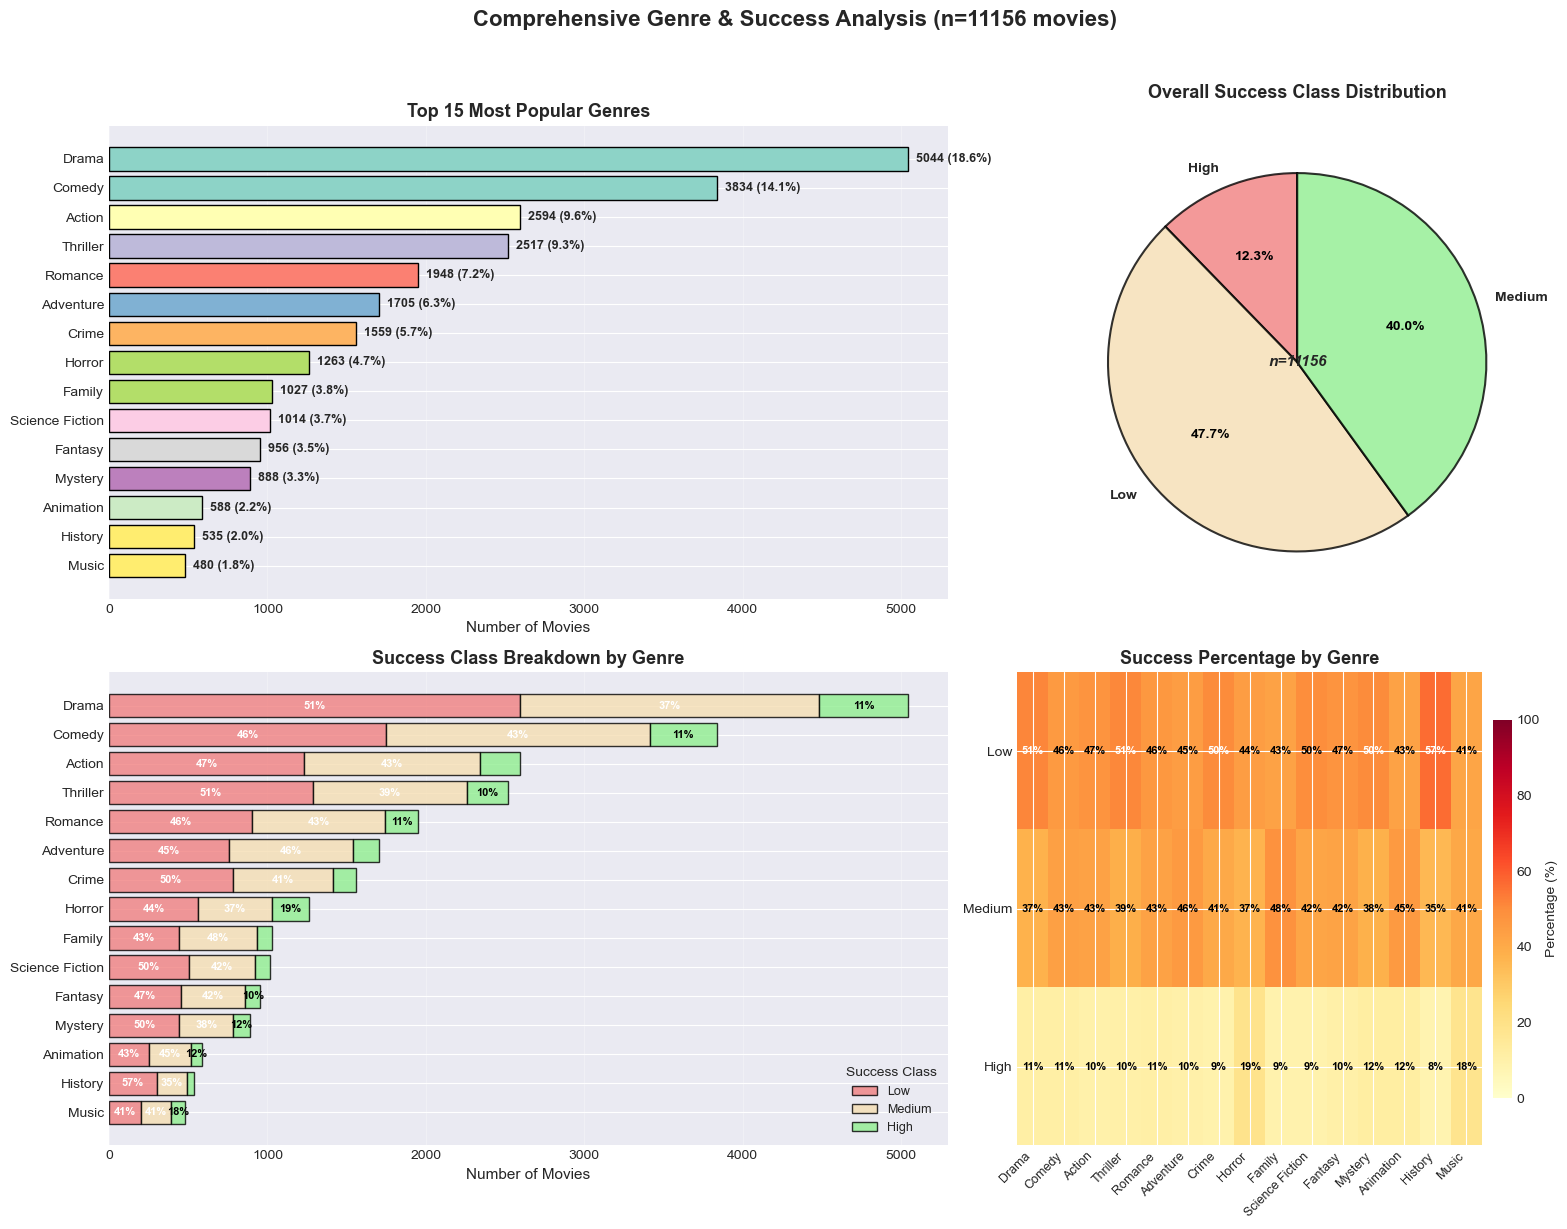

TOP 15 GENRE STATISTICS WITH PERCENTAGES

Overall Success Distribution:
  Low: 47.7%
  Medium: 40.0%
  High: 12.3%

Genre Success Breakdown:
----------------------------------------------------------------------
Drama                5044 movies ( 18.6% of all genre entries)
                        High:  11.2% | Medium:  37.4% | Low:  51.5% →
                        📊 Mixed

Comedy               3834 movies ( 14.1% of all genre entries)
                        High:  11.0% | Medium:  43.4% | Low:  45.7% →
                        📊 Mixed

Action               2594 movies (  9.6% of all genre entries)
                        High:   9.7% | Medium:  42.8% | Low:  47.5% →
                        📊 Mixed

Thriller             2517 movies (  9.3% of all genre entries)
                        High:  10.3% | Medium:  38.7% | Low:  51.1% →
                        📊 Mixed

Romance              1948 movies (  7.2% of all genre entries)
                        High:  10.6% | Medium:  43.0% | Low: 

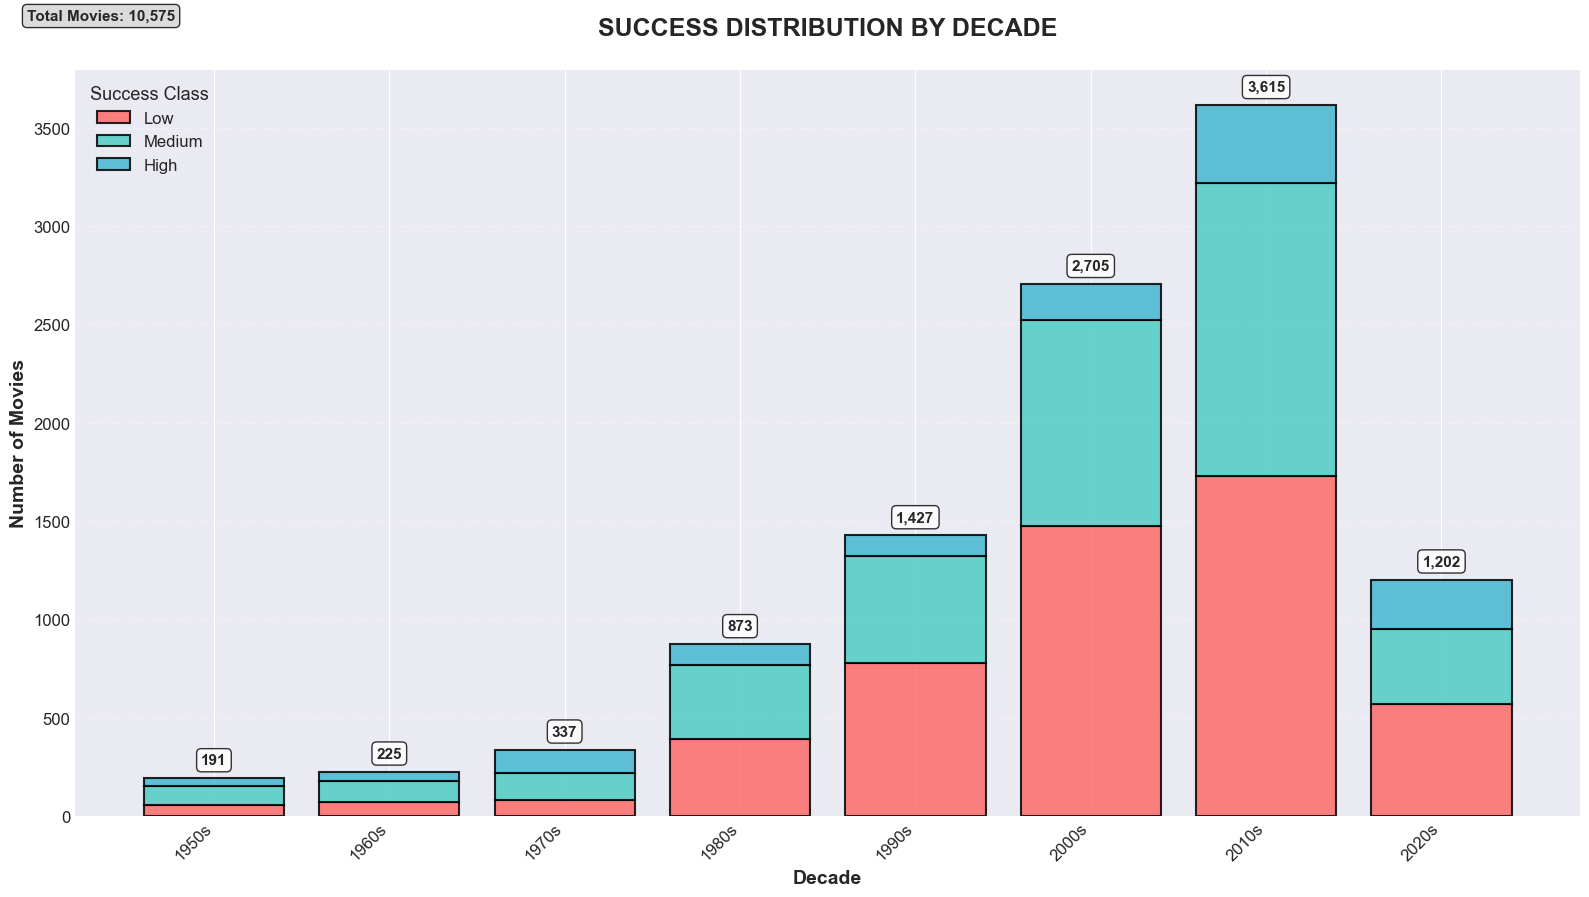


🥧 Creating Plot 2: Overall Success Distribution Pie Chart...


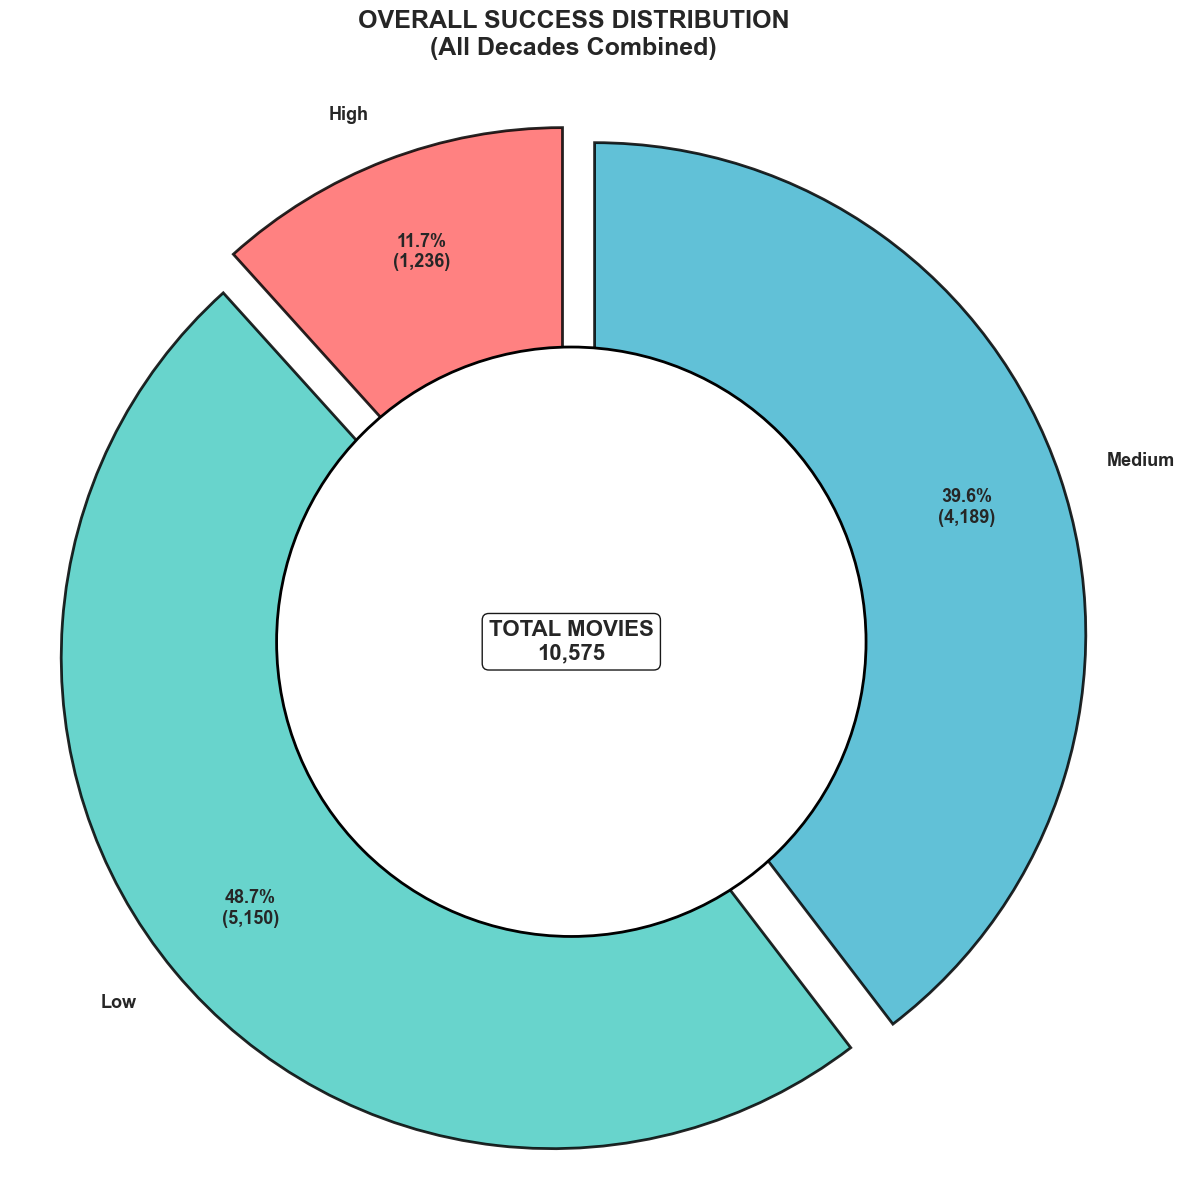


📈 Creating Plot 3: Success Trends Over Decades...


<Figure size 1600x800 with 0 Axes>

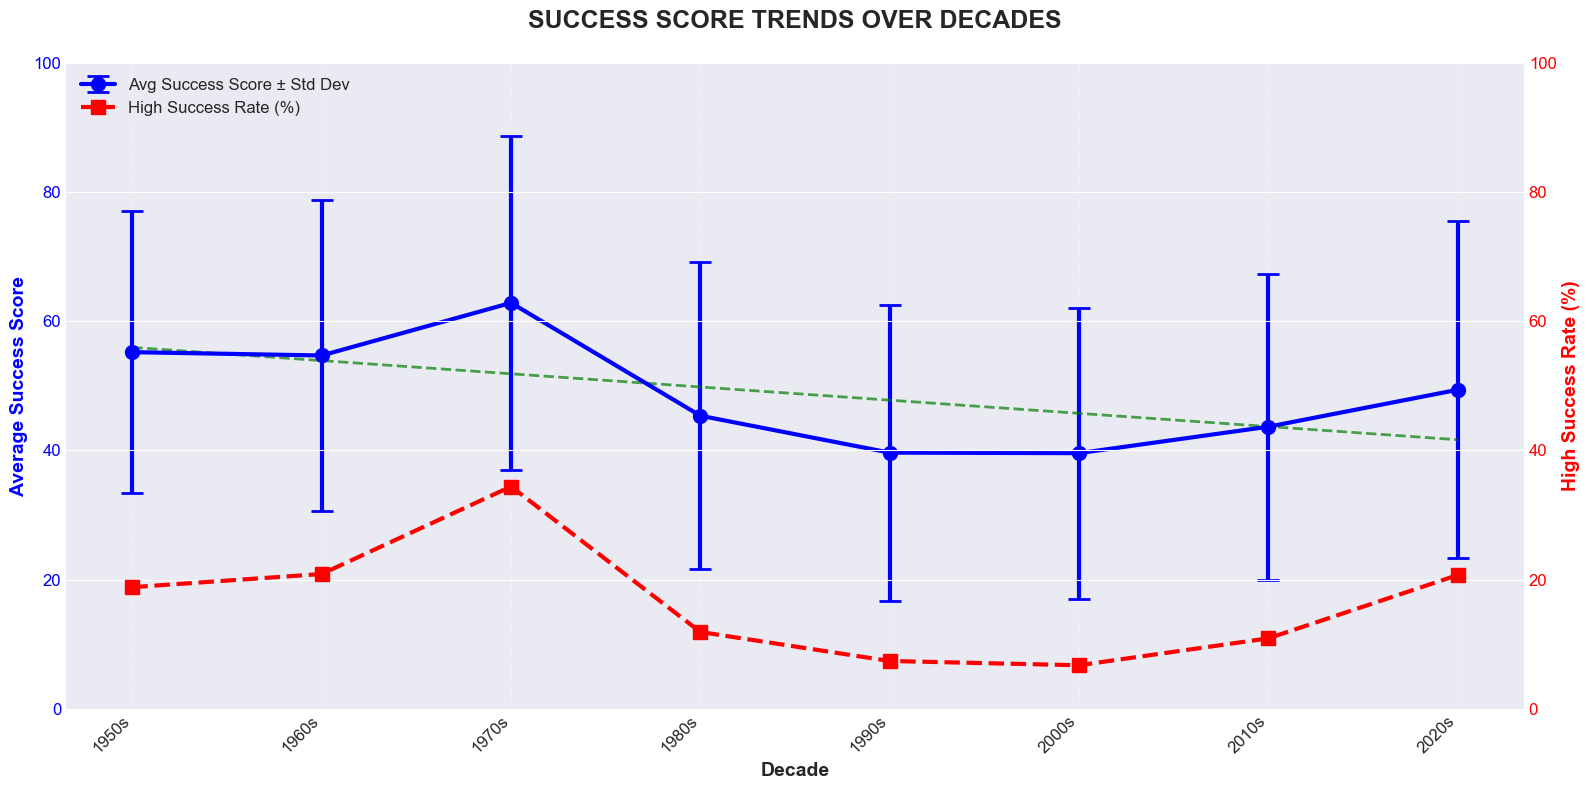


DECADE STATISTICS SUMMARY
Decade  Movies  High%  Medium%  Low%  Avg Score
 1950s     191   18.8     52.9  28.3       55.2
 1960s     225   20.9     47.6  31.6       54.7
 1970s     337   34.4     42.1  23.4       62.8
 1980s     873   11.9     43.3  44.8       45.4
 1990s    1427    7.4     38.0  54.6       39.7
 2000s    2705    6.8     38.6  54.6       39.6
 2010s    3615   10.9     41.2  47.9       43.7
 2020s    1202   20.7     32.0  47.3       49.4

OVERALL SUMMARY
Total movies analyzed: 10,575
Time period covered: 1950s to 2020s
Overall High success rate: 11.7%
Overall average success score: 43.9/100

KEY FINDINGS
🏆 Best Decade: 1970s
   • 34.4% High success rate
   • 337 movies
   • Average score: 62.8/100

⚠️  Most Challenging Decade: 2000s
   • 6.8% High success rate
   • 2,705 movies
   • Average score: 39.6/100

3. Running basic success distribution...


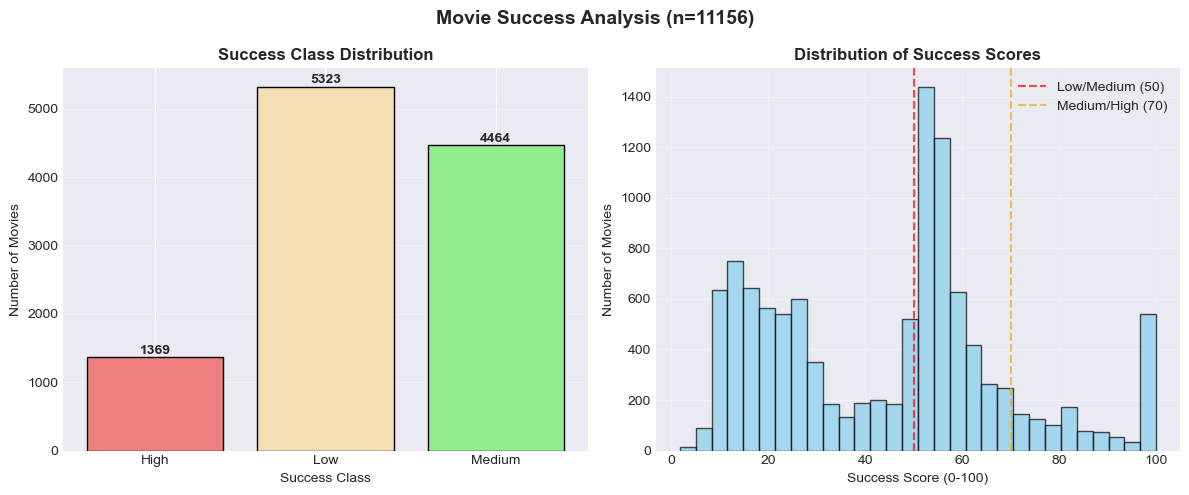

In [10]:
print("="*70)
print("RUNNING ENHANCED VISUALIZATIONS")
print("="*70)

# 1. Basic success distribution (with pie chart included in new functions)
print("\n1. Running enhanced genre analysis with pie chart...")
if 'genres' in df_processed.columns:
    df_genres, genre_counts, genre_percentages = plot_most_popular_genres(df_processed, top_n=15)
else:
    print("   Skipping - no 'genres' column found")

print("\n2. Running decade analysis with pie chart...")
if 'release_date' in df_processed.columns:
    df_with_decades = plot_success_by_decade(df_processed)
else:
    print("   Skipping - no 'release_date' column found")

print("\n3. Running basic success distribution...")

plot_success_distribution_simple(df_processed)

## Machine Learning Algorithms + Models

In [11]:
def create_simplified_model_pipeline(df, target_col='success_class', test_size=0.2):
    """
    Create simplified model pipeline with only Logistic Regression and Random Forest
    """
    # Prepare features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    print(f"Dataset split:")
    print(f"  Training set: {X_train.shape}")
    print(f"  Test set: {X_test.shape}")
    print(f"  Target classes: {y.unique()}")
    
    # Identify feature types
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(include=['object']).columns.tolist()
    
    print(f"\nFeature types:")
    print(f"  Numeric features: {len(numeric_features)}")
    print(f"  Categorical features: {len(categorical_features)}")
    
    # Create preprocessing pipeline
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    # SIMPLIFIED: Only 2 models now
    
    # 1. Logistic Regression - Fast and interpretable
    lr_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            max_iter=1000,
            random_state=42,
            class_weight='balanced',
            C=1.0
        ))
    ])
    
    # 2. Random Forest - Robust and provides feature importance
    rf_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100,  # Reduced from 200 for faster training
            max_depth=10,  # Limited depth for faster training
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1  # Use all CPU cores
        ))
    ])
    
    models = {
        'Logistic Regression': lr_pipeline,
        'Random Forest': rf_pipeline
    }
    
    return models, X_train, X_test, y_train, y_test, preprocessor

def run_fast_model_comparison(models, X_train, X_test, y_train, y_test):
    """
    Train and compare models quickly
    """
    results = {}
    predictions = {}
    
    for name, pipeline in models.items():
        print(f"\n{'='*50}")
        print(f"Training {name}")
        print('='*50)
        
        # Train model (with timing)
        import time
        start_time = time.time()
        pipeline.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Make predictions
        y_pred = pipeline.predict(X_test)
        y_pred_train = pipeline.predict(X_train)
        
        # Calculate metrics
        test_accuracy = accuracy_score(y_test, y_pred)
        train_accuracy = accuracy_score(y_train, y_pred_train)
        test_f1 = f1_score(y_test, y_pred, average='weighted')
        
        results[name] = {
            'test_accuracy': test_accuracy,
            'train_accuracy': train_accuracy,
            'test_f1': test_f1,
            'training_time': training_time
        }
        
        predictions[name] = y_pred
        
        print(f"Training time: {training_time:.2f} seconds")
        print(f"Test Accuracy:  {test_accuracy:.3f}")
        print(f"Train Accuracy: {train_accuracy:.3f}")
        print(f"Test F1-Score:  {test_f1:.3f}")
        
        # Check for overfitting
        accuracy_gap = train_accuracy - test_accuracy
        if accuracy_gap > 0.1:
            print(f"⚠️  Warning: Possible overfitting (gap: {accuracy_gap:.3f})")
        
        # Show classification report for each model
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
    
    return results, predictions

def get_feature_names_from_preprocessor(preprocessor, X_train):
    """
    Extract feature names after preprocessing
    """
    feature_names = []
    
    try:
        # Fit the preprocessor to get feature names
        preprocessor.fit(X_train)
        
        # Get numeric feature names
        if 'num' in preprocessor.named_transformers_:
            num_indices = preprocessor.transformers_[0][2]
            num_features = [X_train.columns[i] for i in num_indices]
            feature_names.extend(num_features)
        
        # Get categorical feature names (after one-hot encoding)
        if 'cat' in preprocessor.named_transformers_:
            cat_indices = preprocessor.transformers_[1][2]
            cat_features = [X_train.columns[i] for i in cat_indices]
            
            # Get the fitted OneHotEncoder
            ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
            
            if hasattr(ohe, 'get_feature_names_out'):
                # Modern sklearn version
                ohe_feature_names = ohe.get_feature_names_out(cat_features)
                feature_names.extend(list(ohe_feature_names))
            else:
                # Older sklearn version - create manual names
                for cat_feat in cat_features:
                    unique_vals = X_train[cat_feat].dropna().unique()
                    for val in unique_vals:
                        feature_names.append(f"{cat_feat}_{val}")
        
        return feature_names
    
    except Exception as e:
        print(f"Warning: Could not extract feature names from preprocessor: {e}")
        # Fallback: create generic feature names
        n_features_total = 0
        for transformer_name, transformer, cols in preprocessor.transformers_:
            if transformer_name == 'num':
                n_features_total += len(cols)
            elif transformer_name == 'cat':
                for col in cols:
                    if X_train[col].dtype == 'object':
                        n_features_total += X_train[col].nunique()
                    else:
                        n_features_total += 1
        
        return [f"feature_{i}" for i in range(n_features_total)]

def analyze_model_results(results, X_train, y_train, models):
    """
    Analyze and visualize model results WITH FIXED FEATURE IMPORTANCE
    """
    import matplotlib.pyplot as plt
    
    # Create comparison table
    results_df = pd.DataFrame(results).T
    results_df = results_df[['test_accuracy', 'train_accuracy', 'test_f1', 'training_time']].round(3)
    
    print("\n" + "="*60)
    print("MODEL COMPARISON SUMMARY")
    print("="*60)
    print(results_df.sort_values('test_f1', ascending=False))
    
    # Find best model
    best_model_name = max(results, key=lambda x: results[x]['test_f1'])
    print(f"\n🎯 BEST MODEL: {best_model_name}")
    print(f"   F1-Score: {results[best_model_name]['test_f1']:.3f}")
    print(f"   Accuracy: {results[best_model_name]['test_accuracy']:.3f}")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Accuracy comparison
    ax1 = axes[0, 0]
    model_names = list(results.keys())
    test_accuracies = [results[name]['test_accuracy'] for name in model_names]
    train_accuracies = [results[name]['train_accuracy'] for name in model_names]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    ax1.bar(x - width/2, train_accuracies, width, label='Train', color='skyblue', edgecolor='black')
    ax1.bar(x + width/2, test_accuracies, width, label='Test', color='lightcoral', edgecolor='black')
    ax1.set_xlabel('Model', fontsize=11)
    ax1.set_ylabel('Accuracy', fontsize=11)
    ax1.set_title('Train vs Test Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    ax1.legend(fontsize=10, loc='upper right')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add accuracy values on bars
    for i, (train_acc, test_acc) in enumerate(zip(train_accuracies, test_accuracies)):
        ax1.text(i - width/2, train_acc + 0.01, f'{train_acc:.3f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax1.text(i + width/2, test_acc + 0.01, f'{test_acc:.3f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 2. F1-Score comparison
    ax2 = axes[0, 1]
    f1_scores = [results[name]['test_f1'] for name in model_names]
    colors = ['#2ecc71' if name == best_model_name else '#95a5a6' for name in model_names]
    
    bars = ax2.bar(model_names, f1_scores, color=colors, alpha=0.8, edgecolor='black')
    ax2.set_xlabel('Model', fontsize=11)
    ax2.set_ylabel('F1-Score', fontsize=11)
    ax2.set_title('Test F1-Score Comparison', fontsize=13, fontweight='bold')
    ax2.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_ylim([0, 1.1])
    
    # Add value labels on bars
    for bar, score in zip(bars, f1_scores):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 3. Training time comparison
    ax3 = axes[1, 0]
    training_times = [results[name]['training_time'] for name in model_names]
    colors = ['#3498db', '#e74c3c']  # Blue for LR, Red for RF
    
    bars = ax3.bar(model_names, training_times, color=colors, alpha=0.8, edgecolor='black')
    ax3.set_xlabel('Model', fontsize=11)
    ax3.set_ylabel('Time (seconds)', fontsize=11)
    ax3.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
    ax3.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar, time_val in zip(bars, training_times):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + max(training_times)*0.01,
                f'{time_val:.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 4. FIXED FEATURE IMPORTANCE for Random Forest
    ax4 = axes[1, 1]
    
    if 'Random Forest' in models:
        try:
            print("\n" + "="*60)
            print("EXTRACTING RANDOM FOREST FEATURE IMPORTANCE")
            print("="*60)
            
            rf_model = models['Random Forest'].named_steps['classifier']
            preprocessor = models['Random Forest'].named_steps['preprocessor']
            
            # Get feature names
            feature_names = get_feature_names_from_preprocessor(preprocessor, X_train)
            
            # Check if we have the right number of features
            n_expected = len(feature_names)
            n_actual = len(rf_model.feature_importances_)
            
            print(f"Expected features: {n_expected}")
            print(f"Actual features in model: {n_actual}")
            
            if n_expected == n_actual or abs(n_expected - n_actual) < 5:
                # Create feature importance DataFrame
                importance_df = pd.DataFrame({
                    'feature': feature_names,
                    'importance': rf_model.feature_importances_
                }).sort_values('importance', ascending=False).head(15)
                
                # Plot
                bars = ax4.barh(range(len(importance_df)), 
                               importance_df['importance'],
                               color='#9b59b6', alpha=0.8, edgecolor='black')
                
                ax4.set_yticks(range(len(importance_df)))
                ax4.set_yticklabels(importance_df['feature'], fontsize=9)
                ax4.invert_yaxis()
                ax4.set_xlabel('Importance Score', fontsize=11)
                ax4.set_title('Random Forest - Top 15 Feature Importance', 
                             fontsize=13, fontweight='bold')
                ax4.grid(axis='x', alpha=0.3, linestyle='--')
                
                # Add importance values on bars
                for i, (bar, importance) in enumerate(zip(bars, importance_df['importance'])):
                    ax4.text(importance + 0.001, i, f'{importance:.4f}', 
                            va='center', fontsize=8, fontweight='bold')
                
                # Print top features
                print("\nTop 15 Most Important Features:")
                print("-" * 60)
                for i, (_, row) in enumerate(importance_df.iterrows(), 1):
                    print(f"{i:2}. {row['feature']:30} : {row['importance']:.4f}")
                    
            else:
                # Use generic feature indices
                print(f"⚠️ Feature count mismatch. Using generic indices.")
                
                importances = rf_model.feature_importances_
                top_indices = np.argsort(importances)[-15:][::-1]
                
                # Create labels
                y_labels = []
                for idx in top_indices:
                    if idx < len(feature_names):
                        y_labels.append(feature_names[idx])
                    else:
                        y_labels.append(f"Feature_{idx}")
                
                # Plot
                bars = ax4.barh(range(15), importances[top_indices],
                               color='#9b59b6', alpha=0.8, edgecolor='black')
                
                ax4.set_yticks(range(15))
                ax4.set_yticklabels(y_labels, fontsize=9)
                ax4.invert_yaxis()
                ax4.set_xlabel('Importance Score', fontsize=11)
                ax4.set_title('Random Forest - Top 15 Features', 
                             fontsize=13, fontweight='bold')
                ax4.grid(axis='x', alpha=0.3, linestyle='--')
                
                # Add values
                for i, (bar, importance) in enumerate(zip(bars, importances[top_indices])):
                    ax4.text(importance + 0.001, i, f'{importance:.4f}', 
                            va='center', fontsize=8, fontweight='bold')
        
        except Exception as e:
            print(f"❌ Error extracting feature importance: {e}")
            ax4.text(0.5, 0.5, 'Feature importance\nextraction failed', 
                    ha='center', va='center', transform=ax4.transAxes,
                    fontsize=11, fontweight='bold', color='darkred')
            ax4.set_title('Feature Importance', fontsize=13, fontweight='bold')
    
    else:
        ax4.text(0.5, 0.5, 'Random Forest model\nnot available', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_title('Feature Importance', fontsize=13, fontweight='bold')
    
    plt.suptitle('Model Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Also show Logistic Regression coefficients if available
    if 'Logistic Regression' in models:
        print("\n" + "="*60)
        print("LOGISTIC REGRESSION COEFFICIENTS (Interpretability)")
        print("="*60)
        
        try:
            lr_model = models['Logistic Regression'].named_steps['classifier']
            preprocessor = models['Logistic Regression'].named_steps['preprocessor']
            
            # Get feature names
            feature_names = get_feature_names_from_preprocessor(preprocessor, X_train)
            
            # Get coefficients for each class
            coefficients = lr_model.coef_
            
            # Create DataFrame for each class
            classes = lr_model.classes_
            for i, cls in enumerate(classes):
                coef_df = pd.DataFrame({
                    'feature': feature_names[:len(coefficients[i])],
                    'coefficient': coefficients[i]
                }).sort_values('coefficient', ascending=False)
                
                print(f"\nTop features for class '{cls}':")
                print("-" * 40)
                # Positive coefficients (increase probability of this class)
                print("Features that INCREASE probability:")
                for _, row in coef_df.head(5).iterrows():
                    print(f"  {row['feature']:30} : {row['coefficient']:+.4f}")
                
                print("\nFeatures that DECREASE probability:")
                for _, row in coef_df.tail(5).iterrows():
                    print(f"  {row['feature']:30} : {row['coefficient']:+.4f}")
                    
        except Exception as e:
            print(f"Could not extract Logistic Regression coefficients: {e}")
    
    return results_df, best_model_name

FAST MODEL TRAINING - LOGISTIC REGRESSION & RANDOM FOREST ONLY

Creating model pipelines...
Dataset split:
  Training set: (8924, 14)
  Test set: (2232, 14)
  Target classes: ['Medium' 'High' 'Low']

Feature types:
  Numeric features: 7
  Categorical features: 7

Training and comparing models...

Training Logistic Regression
Training time: 26.71 seconds
Test Accuracy:  0.969
Train Accuracy: 0.999
Test F1-Score:  0.969

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.99      0.97       274
         Low       1.00      0.95      0.97      1065
      Medium       0.94      0.98      0.96       893

    accuracy                           0.97      2232
   macro avg       0.96      0.97      0.97      2232
weighted avg       0.97      0.97      0.97      2232


Training Random Forest
Training time: 8.17 seconds
Test Accuracy:  0.873
Train Accuracy: 0.880
Test F1-Score:  0.876

Classification Report:
              precision    reca

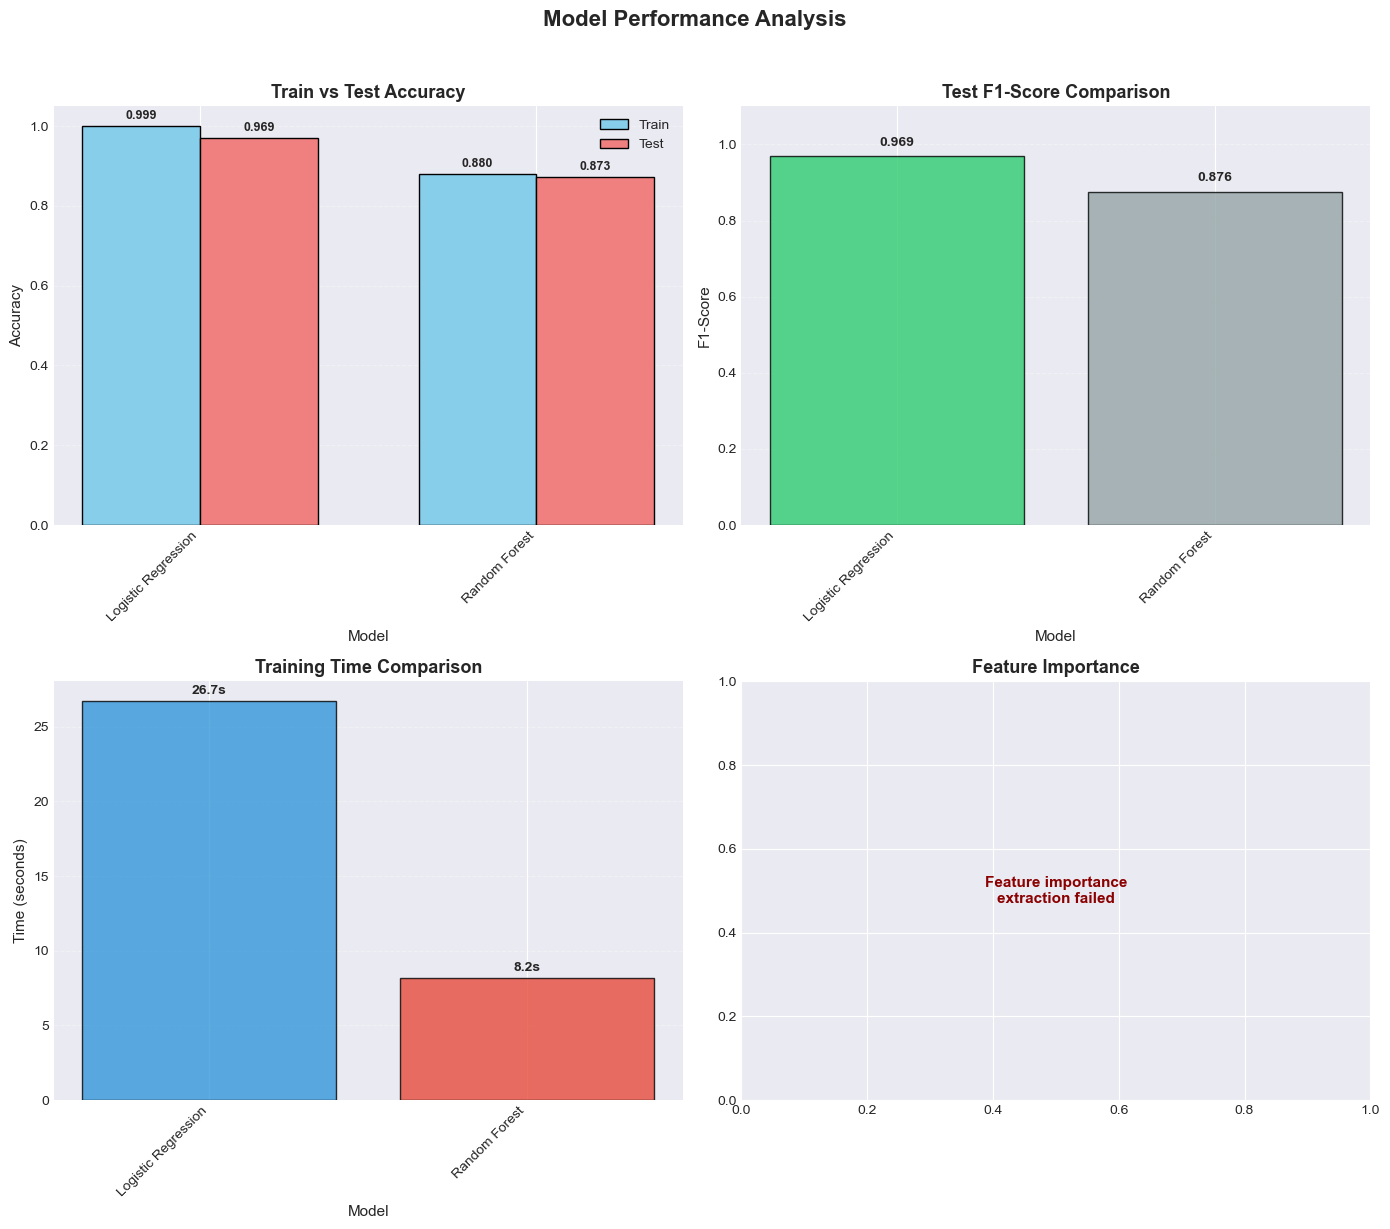


LOGISTIC REGRESSION COEFFICIENTS (Interpretability)
Could not extract Logistic Regression coefficients: All arrays must be of the same length

DETAILED ANALYSIS FOR BEST MODEL: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.99      0.97       274
         Low       1.00      0.95      0.97      1065
      Medium       0.94      0.98      0.96       893

    accuracy                           0.97      2232
   macro avg       0.96      0.97      0.97      2232
weighted avg       0.97      0.97      0.97      2232


Confusion Matrix:
[[ 270    0    4]
 [   0 1014   51]
 [  13    1  879]]


In [12]:
print("="*70)
print("FAST MODEL TRAINING - LOGISTIC REGRESSION & RANDOM FOREST ONLY")
print("="*70)

print("\nCreating model pipelines...")
models, X_train, X_test, y_train, y_test, preprocessor = create_simplified_model_pipeline(df_processed)

print("\nTraining and comparing models...")
results, predictions = run_fast_model_comparison(models, X_train, X_test, y_train, y_test)

print("\nAnalyzing results...")
results_df, best_model_name = analyze_model_results(results, X_train, y_train, models)

# Show detailed predictions for best model
print(f"\n{'='*60}")
print(f"DETAILED ANALYSIS FOR BEST MODEL: {best_model_name}")
print('='*60)

best_pipeline = models[best_model_name]
y_pred_best = predictions[best_model_name]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)

# Show feature importance for Random Forest
if best_model_name == 'Random Forest':
    print(f"\nFeature Importance from Random Forest:")
    rf_model = best_pipeline.named_steps['classifier']
    
    # Try to get feature names
    try:
        # Get preprocessor
        preprocessor = best_pipeline.named_steps['preprocessor']
        
        # For numeric features
        if 'num' in preprocessor.named_transformers_:
            num_indices = preprocessor.transformers_[0][2]
            num_features = [X_train.columns[i] for i in num_indices]
            print(f"  Numeric features: {len(num_features)}")
        
        # For categorical features  
        if 'cat' in preprocessor.named_transformers_:
            cat_indices = preprocessor.transformers_[1][2]
            cat_features = [X_train.columns[i] for i in cat_indices]
            print(f"  Categorical features: {len(cat_features)}")
            
    except:
        print("  (Feature names not available in current format)")

## Analysis

The scores table comes from creating the model pipeline to analyze the relationship in the film dataset. The accuracy is different for each model and it is ultimately meant to ensure that with the math used, it can actively use the factors and take each entry into account for the success class that it belongs to. 

The classification report gives better insight on the information that comes from the Logistic Regression model. The precision, recall, and f1-score columns give high markings to the regression model’s testing data. These columns along with the macro and weighted average are tactics that make up the overall accuracy for the model. The support column accounts for the samples of the testing data and it’s split through the success class. With this accuracy, it brings inquiries on if the next model (Random Forest) can compare. 

The classification report illustrates the statistics that come from the Random Forest algorithm. The precision, recall, and f1-score columns are lower than the regression model but it’s still fairly consistent among the columns (not including support). The accuracy and average rows in the figure are in the 0.80-0.89 range. It may not be as high or nearly perfect as the logistic regression, but that can be a strength as it has a more realistic approach to active testing and training. 

With the comparison of these two models, logistic regression is the better model to use for the analysis of a movie’s success. The random forest model can be improved to make it more functional among these datasets and others. The reasoning for the regression model being better is because of the overall average and accuracy that it showed during testing and training. I will take into consideration the fact that the set used only 11,000 samples and around 15 features out of the 1,000,000+ dataset that existed before preprocessing. However, this sample set is nicer to at least begin on before expanding into a larger database.


## Save Processed Data and Model Results

In [13]:
# Save processed data
df_processed.to_csv('movies_processed.csv', index=False)
print("Saved processed data to 'movies_processed.csv'")

# Save model results
results_df.to_csv('model_results.csv')
print("Saved model results to 'model_results.csv'")

Saved processed data to 'movies_processed.csv'
Saved model results to 'model_results.csv'


This code is used to save the updated processed data into a new file which makes it easier to come back to.

## Conclusion

In conclusion, this project has been a very interesting experience to complete the end of my intro to machine learning class. I felt that this project showcased the best approach to applying the concepts I have learned. The logistic regression algorithm made me feel at peace because of what I have learned over this fall semester, but it was interesting to dive into the random forest algorithm. The best thing about these algorithms is that they were both used for classification with the success classes so it was better to combine the two. However, it was a challenge to settle for a topic that fit with my interests along with finding a dataset that had a large amount of samples and features. Some other datasets had very little samples or plenty of string data types in the .csv file that made it frustrating. I did overcome this eventually with the Kaggle dataset that I found, and the preprocessing approach I implemented made it easier to handle the set. One more challenge I never fully understood was the feature importance portion of the analysis. I see that there were errors during the preprocessing approach and it may be due to text constraints within the dataset. Nevertheless, I still had a great process to learn more about the application of machine learning techniques.

Throughout the process, I learned that there are various features to consider when production companies choose when creating sequels or remakes. I believe that revenue and the vote average are the most important columns in the dataset. The economic status that a previously released movie can have in decision-making for a sequel is useful to bring the nostalgia back to viewers who have seen the movie in theaters or through other outlets. Another thing I learned was how to actively preprocess data to make it applicable to my research. I started with only dropping some columns to get the hang of it, but I got better when I made the success classes and their scores. Overall, the project improved my understanding of cinematography and analyzed the degree to which a movie can be greenlit for production and released in theaters that can impact the next generation of viewers.


## Acknowledgement

I, Charles Diggs, acknowledge that I used DeepSeek to assist in completing this final project. It was used in the initial stages mostly to settle on a topic that would be significant to focus on for my report. I asked for various topics until I settled on the degree classification for a film’s success.

I also used DeepSeek to add better formatting within my functions to make it easier and readable to those who access my code. Some of the comments in the functions include steps to better explain what the code means.

The last piece that I used the AI for was to explain more of the why to the specific ML algorithms (mainly Random Forest). It was useful in showing the differences between the two and how it was the best choice besides other techniques that wouldn’t have been as applicable to my problem statement.
